In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c, sigma_T, m_p

In [2]:
3e4 * u.Lsun * G * 1e8 / (c**5)

<Quantity 8.2684378e-41 s3 solLum / (kg m2)>

In [3]:
_.si

<Quantity 3.16515799e-14>

In [4]:
M = 1e7*u.Msun
lambda_d = 0.01
eta_d = 0.1 
L_edd = 1.26e38*(M/u.Msun) * u.erg / u.s
Mdot_edd = L_edd/(eta_d*c*c)
Mdot = lambda_d*Mdot_edd
Mdot.to(u.kg/u.s)

<Quantity 1.40193907e+20 kg / s>

In [5]:
# Create disk object
disk = AGNDisk()

# Set required parameters
disk.M = M        # Central black hole mass
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

# Accretion rate as a fraction of the Eddington limit
#MdotEddFrac = 0.1             # Fraction of Eddington accretion rate



disk.Mdot = Mdot

# Generate the disk profile
# rvals can be passed as dimensionless (multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
#df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
df = disk.spacehub_pretab(rvals=np.logspace(1, 9, 5000))

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1168: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [2463, 2663) around index 2563 (R/Rg ≈ 126363.1) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  self.generate(rvals=rvals)


In [6]:
if False:
    # Create disk object
    disk_SuperE = AGNDisk()

    # Set required parameters
    disk_SuperE.M = 1e8 * u.Msun          # Central black hole mass
    disk_SuperE.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

    # Accretion rate as a fraction of the Eddington limit
    MdotEddFrac = 1.3              # Fraction of Eddington accretion rate
    epsilon = 0.1                   # Radiative efficiency (0.1 for Schwarzschild BH)

    kappa = sigma_T / m_p           # Electron scattering opacity
    L_Edd = 4 * np.pi * G * disk_SuperE.M * c / kappa   # Eddington luminosity
    Mdot_Edd = (L_Edd / (epsilon * c**2)).to(u.kg / u.s)  # Eddington accretion rate
    disk_SuperE.Mdot = MdotEddFrac * Mdot_Edd

    # Generate the disk profile
    # rvals can be passed as dimensionless (multiples of Rg) or with units
    # If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
    #df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
    df_super_eddington = disk_SuperE.spacehub_pretab(rvals=np.logspace(1, 9, 500))

In [7]:
disk.model

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,gamma,f_thermal,zone,grad_T,grad_Sigma,grad_P,grad_P_raw,grad_Sigma_raw,v_disk
0,1.476625e+11,1.000000e+01,614403.174639,2.955591e-04,3.843537e+07,360614.667690,5.616851e+08,2.025519e+13,166006.268977,6.651411e+06,1.333333,0.810968,Standard,0.351791,0.111990,1.453592,1.453592,0.111990,9.480170e+07
1,1.482076e+11,1.003692e+01,613607.236516,2.936371e-04,3.823005e+07,360825.317530,5.651282e+08,2.039126e+13,165937.777591,6.621344e+06,1.333333,0.810968,Standard,0.352222,0.106842,1.454455,1.454455,0.106842,9.462719e+07
2,1.487548e+11,1.007397e+01,612810.381348,2.917515e-04,3.802559e+07,361020.093083,5.685673e+08,2.052642e+13,165875.607632,6.590870e+06,1.333333,0.810968,Standard,0.353077,0.096610,1.456163,1.456163,0.096610,9.445300e+07
3,1.493039e+11,1.011116e+01,612012.653313,2.899017e-04,3.782198e+07,361199.183696,5.720022e+08,2.066067e+13,165819.673819,6.560005e+06,1.333333,0.810968,Standard,0.353914,0.086505,1.457838,1.457838,0.086505,9.427913e+07
4,1.498551e+11,1.014849e+01,611214.095180,2.880866e-04,3.761923e+07,361362.777171,5.754331e+08,2.079401e+13,165769.892877,6.528760e+06,1.333333,0.810968,Standard,0.354736,0.076525,1.459482,1.459482,0.076525,9.410558e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.455020e+19,9.853686e+08,2.518365,1.027352e-21,1.017901e-14,3147.699381,4.795577e+18,1.509503e+21,0.009853,1.000000e+00,1.333333,0.999988,Self-Reg,0.749336,1.499987,2.999974,2.999974,1.499987,7.841318e+03
4996,1.460391e+19,9.890063e+08,2.511421,1.016057e-21,1.006711e-14,3147.699532,4.822157e+18,1.517870e+21,0.009799,1.000000e+00,1.333333,0.999988,Self-Reg,0.749338,1.499987,2.999974,2.999974,1.499987,7.819897e+03
4997,1.465783e+19,9.926573e+08,2.504496,1.004887e-21,9.956435e-15,3147.699682,4.848885e+18,1.526283e+21,0.009745,1.000000e+00,1.333333,0.999988,Self-Reg,0.749340,1.499987,2.999974,2.999974,1.499987,7.798496e+03
4998,1.471194e+19,9.963219e+08,2.497590,9.938396e-22,9.846977e-15,3147.699832,4.875760e+18,1.534743e+21,0.009691,1.000000e+00,1.333333,0.999988,Self-Reg,0.749342,1.499987,2.999974,2.999974,1.499987,7.777115e+03


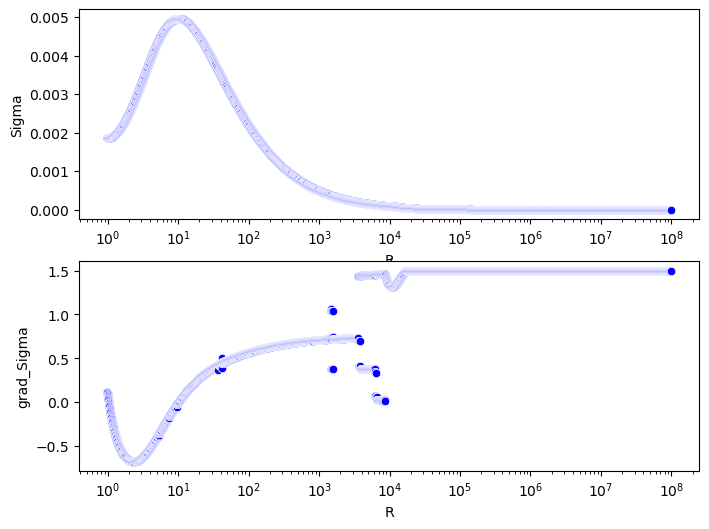

In [8]:
if True:
    fig, axes = plt.subplots(2,1, figsize=(8,6))
    ax = axes.flatten()[0]
    sns.scatterplot(data=df, x="R", y="Sigma", ax=ax, color="blue")
    ax.set_xscale("log")
    ax = axes.flatten()[1]
    sns.scatterplot(data=df, x="R", y="grad_Sigma", ax=ax, color="blue")
    ax.set_xscale("log")

In [9]:
if True: #Write out
    df.to_csv("../../SpaceHub/src/interaction/disk_tab/SG_01Edd_1e7Msun.csv", index=False)